## SUMO Identification Benchmarking (HEK)

This analysis compares peptide-spectrum match (PSM) identification performance across multiple search pipelines and configurations, including MaxQuant-based workflows, Percolator rescoring, and MSFragger/FragPipe runs.

### What it does
- Aggregates PSM outputs from different pipelines
- Standardizes and filters target/decoy results
- Compares score and PEP distributions
- Evaluates overlap and uniqueness of identifications
- Generates summary plots and figures

### Inputs
- Search result tables (MaxQuant, Percolator, MSFragger)

### Outputs
- Comparative score/PEP distributions
- Identification overlap summaries

Run the notebook top-to-bottom after updating paths to local data.

In [6]:
import os
import pandas as pd
import numpy as np
import itertools
import re
from collections import Counter

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial" 
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from upsetplot import UpSet

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':   '#d81159', 
    'Unique Standard':    '#d81159',
    'SBM_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#0e8a1a', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'SBM_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'MSFragger 3nl Percolator': '#e35f00', 
    'Unique MSFragger': '#60435f'
}

In [8]:
to_use = ['SBM 3', 'SBM 3 no fdr']
custom_order = ['VM', 'Standard', 'SBM 3', 'SBM 8']

# Importing the data

In [9]:
fig_dir = '../review_'
root_dir = '../MQ_final_results'

msfragger_folder_path = '../MSFragger_runs'
msfragger_folder_path_review = '../SUMO_fragpipe_review_runs'

per_path3 = '../percolator.target.psms.txt'
per_path3_decoys = '../percolator.decoy.psms.txt'

In [10]:
# This code loads the data into a dataset 
# The parent folder defines the name of the dataset into a new column 

dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            if parent_folder in to_use:
                df = pd.read_csv(file_path, delimiter="\t")
                
                new_columns = {}
                for col in df.columns:
                    if 'SUMO2' in col:
                        new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                        new_columns[col] = new_col_name
                
                df.rename(columns=new_columns, inplace=True)
                df['Dataset'] = parent_folder 
                # contruct percolator id for merging identifications 
                df['PSMId'] = df.apply(lambda x: f"{'decoy' if pd.notna(x['Reverse']) else 'target'}_0_{x['Scan number']}_{x['Raw file']}_{x['Charge']}_1", axis=1)
    
                dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/1687758019.py:9: DtypeWarning: Columns (59,60,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [11]:
big_df['Dataset'].value_counts()

SBM 3 no fdr    863245
SBM 3           244917
Name: Dataset, dtype: int64

# Preprocessing

* cleanup modified sequence
* filter reverse hits
* filter contaminants

In [12]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)
big_df['Modified sequence'] = big_df['Modified sequence'].str.replace(r'st_o_SUMO2/3-DVFQQQTGG|ST_2_SUMO2/3-DVFQQQTGG|SBM_4_o_SUMO2/3-DVFQQQTGG|SBM_5_o_SUMO2/3-DVFQQQTGG|SBM_3_o_SUMO2/3-DVFQQQTGG|SBM_2_o_SUMO2/3-DVFQQQTGG|SBM_8_o_SUMO2/3-DVFQQQTGG|SBM_0_o_SUMO2/3-DVFQQQTGG', 'su', regex=True)

In [13]:
big_df['SUMOylated_peptide'] = (
    big_df['Modified sequence']
    .astype(str)
    .str.replace(r'\.', '', regex=True)
    .str.replace(r'\[ac\]', '', regex=True)
    .str.replace(r'\[ox\]', '', regex=True)
    .str.replace('_', '') 
    .str.replace(r'\(su\)', '[su]', regex=True)
    .str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True)
    .str.replace(r'\(Oxidation \(M\)\)', '', regex=True)
)

In [14]:
#The MaxQuant data folder contained all MQ output, so we'll extract the dataset here 
no_fdr_set = big_df[big_df['Dataset'] == 'SBM 3 no fdr']
big_df_sbm3 = big_df[big_df['Dataset'] != 'SBM 3 no fdr']

# Filtering Dataset and separation 

Separeate into set with all PSMs, SUMOylated PSMs and unique SUMOylated PSMs. 

In [15]:
# Loading MaxQuant data
big_df_sbm3["No. of PSMs"] = big_df_sbm3["SUMOylated_peptide"].map(big_df_sbm3["SUMOylated_peptide"].value_counts())
SBM3_SUMO = big_df_sbm3[big_df_sbm3['SUMOylated_peptide'].str.contains(r'\[su\]', na=False)] 
SBM3_SUMO = SBM3_SUMO[SBM3_SUMO['Contaminant'] != '+']
SBM3_SUMO['Reverse'].fillna('-', inplace=True)
SBM3_SUMO = SBM3_SUMO[SBM3_SUMO['Reverse'] != '+']
SBM3_SUMO_unique = SBM3_SUMO.drop_duplicates(subset=['SUMOylated_peptide'])

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/3257060171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  big_df_sbm3["No. of PSMs"] = big_df_sbm3["SUMOylated_peptide"].map(big_df_sbm3["SUMOylated_peptide"].value_counts())


In [16]:
# Loading percolator data 
df_per = pd.read_csv(per_path3, delimiter="\t")
df_per['Dataset'] = "MQ SBM 3 Percolator"

df_per_decoys = pd.read_csv(per_path3_decoys, delimiter="\t")
df_per_decoys['Dataset'] = "MQ SBM 3 Percolator Decoys"

df_per_sig_q = df_per[df_per['q-value'] <= 0.01]
df_per_sig_q = df_per_sig_q[
    ~df_per_sig_q['proteinIds'].str.contains(r'CON_', na=False)
]

df_sumo_per = df_per_sig_q[df_per_sig_q['peptide'].str.contains(r'\[su\]', na=False)] 
df_sumo_per["No. of PSMs"] = df_sumo_per["peptide"].map(df_sumo_per["peptide"].value_counts())

#df_sumo_per_merged = df_sumo_per.merge(no_fdr_set, on='PSMId', how='left')

df_sumo_per_unique = df_sumo_per.drop_duplicates(subset=['peptide']) 

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/2827296817.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sumo_per["No. of PSMs"] = df_sumo_per["peptide"].map(df_sumo_per["peptide"].value_counts())


In [17]:
df_per_review = pd.read_csv(per_path3_review_noreset, delimiter="\t")
df_per_review['Dataset'] = "MQ SBM 3 Percolator review"

df_per_sig_q_review = df_per_review[df_per_review['q-value'] <= 0.01] 
df_per_sig_q_review = df_per_sig_q_review[
    ~df_per_sig_q_review['proteinIds'].str.contains(r'CON_', na=False)
]

df_sumo_per_review = df_per_sig_q_review[df_per_sig_q_review['peptide'].str.contains(r'\[su\]', na=False)] 
df_sumo_per_review["No. of PSMs"] = df_sumo_per_review["peptide"].map(df_sumo_per_review["peptide"].value_counts())

#df_sumo_per_merged_review = df_sumo_per_review.merge(no_fdr_set, on='PSMId', how='left') 

df_sumo_per_unique_review = df_sumo_per_review.drop_duplicates(subset=['peptide'])

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/1409524267.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sumo_per_review["No. of PSMs"] = df_sumo_per_review["peptide"].map(df_sumo_per_review["peptide"].value_counts())


In [18]:
df_per_review_reset = pd.read_csv(per_path3_review_reset, delimiter="\t")
df_per_review_reset['Dataset'] = "MQ SBM 3 Percolator-RESET"

df_per_sig_q_review_reset = df_per_review_reset[df_per_review_reset['q-value'] <= 0.01] 
df_per_sig_q_review_reset = df_per_sig_q_review_reset[
    ~df_per_sig_q_review_reset['proteinIds'].str.contains(r'CON_', na=False)
]

df_sumo_per_review_reset = df_per_sig_q_review_reset[df_per_sig_q_review_reset['peptide'].str.contains(r'\[su\]', na=False)] 
df_sumo_per_review_reset["No. of PSMs"] = df_sumo_per_review_reset["peptide"].map(df_sumo_per_review_reset["peptide"].value_counts())

#df_sumo_per_merged_review = df_sumo_per_review.merge(no_fdr_set, on='PSMId', how='left') 

df_sumo_per_unique_review_reset = df_sumo_per_review_reset.drop_duplicates(subset=['peptide'])

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/1781762955.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sumo_per_review_reset["No. of PSMs"] = df_sumo_per_review_reset["peptide"].map(df_sumo_per_review_reset["peptide"].value_counts())


In [19]:
mq_peptides = SBM3_SUMO_unique["SUMOylated_peptide"]
set_sbm3 = set(mq_peptides)

per_peptides = df_sumo_per_unique["peptide"].str.replace('\.', '').str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
set_sbm3_per = set(per_peptides)

per_peptides_review = df_sumo_per_unique_review["peptide"].str.replace('\.', '').str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
set_sbm3_per_review = set(per_peptides_review)

per_peptides_review_reset = df_sumo_per_unique_review_reset["peptide"].str.replace('\.', '').str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
set_sbm3_per_review_reset = set(per_peptides_review_reset)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/675578506.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  per_peptides = df_sumo_per_unique["peptide"].str.replace('\.', '').str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/675578506.py:7: FutureWarning: The default value of regex will change from True to False in a future version.
  per_peptides_review = df_sumo_per_unique_review["peptide"].str.replace('\.', '').str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/675578506.py:10: FutureWarning: The default value of regex will change from True to False in a future version.
  per_peptides_review_reset = df_sumo_per_unique_review_reset["peptide"].str.replace('\.', '').str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex

In [57]:
def process_psm_file(psm_file, Dataset_name):
    """Reads and processes a single psm.tsv file."""
    df_psm = pd.read_csv(psm_file, delimiter="\t")
    df_psm['Dataset'] = Dataset_name

    df_filtered = df_psm[~df_psm['Protein ID'].str.contains('rev_', na=False)]
    #df_filtered = df_psm[df_psm['Modified Peptide'].notna()]
    df_filtered = df_filtered[df_filtered['Is Contaminant'] == False]

    df_filtered["No. of PSMs"] = df_filtered["Modified Peptide"].map(df_filtered["Modified Peptide"].value_counts())
    
    df_filtered_sumo = df_filtered[df_filtered['Modified Peptide'].str.contains(r'\[1089\]', na=False)]
    #df_filtered_sumo = df_filtered_sumo[~df_filtered_sumo['Protein ID'].str.contains('rev_', na=False)]

    df_filtered_sumo['sumoylated_peptides'] = (
        df_filtered_sumo['Modified Peptide']
        .str.replace(r'\[1089\]', '[su]', regex=True)
        .str.replace(r'\[43\]', '', regex=True)
        .str.replace(r'\[147\]', '', regex=True)
    )
    
    # Remove duplicate sumo rows
    #df_filtered_sumo = df_filtered_sumo[~df_filtered_sumo['Assigned Modifications'].str.contains(r'(K\(960\.4301\)).*\1', regex=True)]
    df_unique_msfragger_sumo = df_filtered_sumo.drop_duplicates(subset=['sumoylated_peptides'])
    
    # Extract modification positions
    #df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')
    
    return df_psm, df_filtered, df_filtered_sumo, df_unique_msfragger_sumo

def process_folder(folder_path):
    """Processes all psm.tsv files in a folder and combines them into a single DataFrame."""
    dfs = []
    all_dfs = []
    all_sumos = []
    all_unique = []
    
    for root, _, files in os.walk(folder_path):
        if "psm.tsv" in files:
            Dataset_name = os.path.basename(root)
            psm_path = os.path.join(root, "psm.tsv")
            print(f"Processing: {Dataset_name}")
            df, psms, sumos, unique_sumo  = process_psm_file(psm_path, Dataset_name)
            dfs.append(df)
            all_dfs.append(psms)
            all_sumos.append(sumos)
            all_unique.append(unique_sumo)

    unfiltered_df = pd.concat(dfs, ignore_index=True)
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df_s = pd.concat(all_sumos, ignore_index=True)
    combined_df_u = pd.concat(all_unique, ignore_index=True)
    
    return unfiltered_df, combined_df, combined_df_s, combined_df_u

msfraggger_unfiltered, msfragger_psms, msfragger_sumo, msfragger_unique_sumo = process_folder(msfragger_folder_path_review)

Processing: MSFragger 3nl Percolator


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/3757295889.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo['sumoylated_peptides'] = (


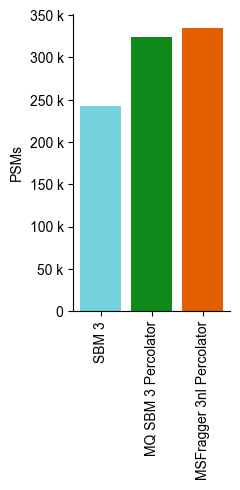

In [21]:
dfs = [
    big_df_sbm3,
    df_per_sig_q,
    msfragger_psms
]

all_counts = pd.concat([df['Dataset'].value_counts() for df in dfs])

fig, ax = plt.subplots(figsize=(2.5, 5))
bars = ax.bar(all_counts.index, all_counts.values, 
    color=[color_map.get(Dataset, 'grey') for Dataset in all_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

ax.set_xlabel('')
ax.set_ylabel('PSMs')
ax.set_title('')
ax.set_xticks(all_counts.index) 
ax.set_xticklabels(all_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_psms_wmsfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show() 

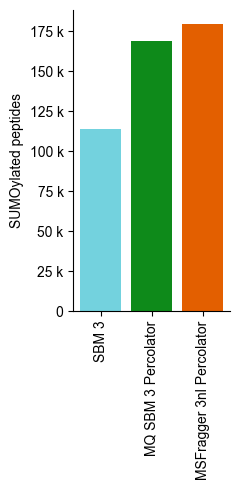

In [22]:
dfs_sumo = [
    SBM3_SUMO,
    df_sumo_per,
    msfragger_sumo
]

filtered_counts_sumo = pd.concat(
    [df['Dataset'].value_counts() for df in dfs_sumo]
)

fig, ax = plt.subplots(figsize=(2.5, 5))
bars_un = ax.bar(
    filtered_counts_sumo.index, 
    filtered_counts_sumo.values, 
    color=[color_map.get(Dataset, 'grey') for Dataset in filtered_counts_sumo.index]
)

#for bar in bars_un:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_sumo.index) 
ax.set_xticklabels(filtered_counts_sumo.index, rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()

file_path = fig_dir + "all_sumo_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

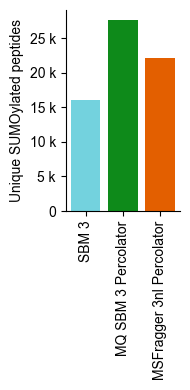

In [39]:
dfs = [
    SBM3_SUMO_unique,
    df_sumo_per_unique,
    msfragger_unique_sumo
]

filtered_counts_unique = pd.concat(
    [df['Dataset'].value_counts() for df in dfs]
)

fig, ax = plt.subplots(figsize=(2, 4))

bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(Dataset, 'grey') for Dataset in filtered_counts_unique.index]
)



ax.set_xlabel('')
ax.set_ylabel('Unique SUMOylated peptides')
ax.set_title('')
ax.set_xticks(range(len(filtered_counts_unique)))
ax.set_xticklabels(filtered_counts_sumo.index, rotation=90)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "unique_sumo_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

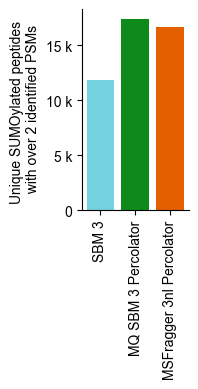

In [40]:
dfs = [
    SBM3_SUMO_unique,
    df_sumo_per_unique,
    msfragger_unique_sumo
]

filtered_counts_unique = pd.concat(
    [
        df.loc[df["No. of PSMs"] >= 2, "Dataset"].value_counts()
        for df in dfs
    ]
)

fig, ax = plt.subplots(figsize=(2.2, 4))

bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(Dataset, 'grey') for Dataset in filtered_counts_unique.index]
)

ax.set_xlabel('')
ax.set_ylabel('Unique SUMOylated peptides \n with over 2 identified PSMs')
ax.set_title('')

ax.set_xticks(range(len(filtered_counts_unique)))
ax.set_xticklabels(filtered_counts_sumo.index, rotation=90)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "unique_sumo_peptides_w_msfragger_over2.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

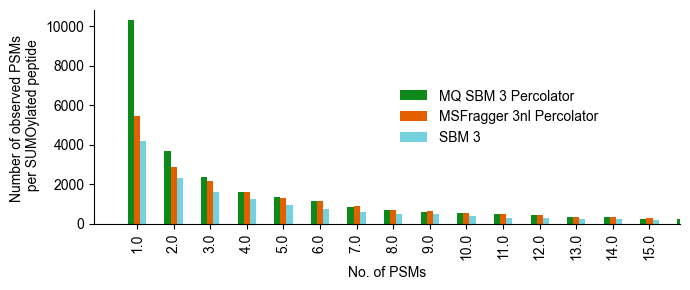

In [28]:
combined_df = pd.concat(
    [
        SBM3_SUMO_unique[['Dataset', 'No. of PSMs']],
        df_sumo_per_unique[['Dataset', 'No. of PSMs']],
        msfragger_unique_sumo[['Dataset', 'No. of PSMs']]
    ],
    ignore_index=True
)

combined_df['No. of PSMs'] = pd.to_numeric(
    combined_df['No. of PSMs'], errors='coerce'
)
combined_df = combined_df.dropna(subset=['No. of PSMs'])

pivot_counts = (
    combined_df
    .groupby(['Dataset', 'No. of PSMs'])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

Datasets = pivot_counts.index
psm_vals = pivot_counts.columns

x = np.arange(len(psm_vals))
width = 0.5 / len(Datasets)

fig, ax = plt.subplots(figsize=(7, 3))

for i, ds in enumerate(Datasets):
    ax.bar(
        x + i * width,
        pivot_counts.loc[ds],
        width,
        label=ds,
        color=color_map.get(str(ds), "#999999")  # fallback gray if missing
    )

ax.set_xticks(x + width * (len(Datasets) - 1) / 2)
ax.set_xticklabels(psm_vals.astype(str), rotation=90)
ax.set_ylabel("Number of observed PSMs \n per SUMOylated peptide")
ax.set_xlabel("No. of PSMs")
ax.set_xlim(-1, 15)

legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(0.5, 0.5),
    frameon=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
file_path = fig_dir + "psms_per_peptide.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

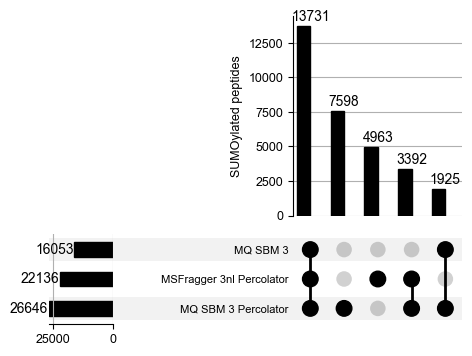

In [29]:
# Start with your existing SBM sets
all_sets = {
    "MQ SBM 3": set_sbm3,
    "MQ SBM 3 Percolator": set_sbm3_per,
}

msfrag_sets = {
    f"{dataset}": set(df['sumoylated_peptides'])
    for dataset, df in msfragger_unique_sumo.groupby('Dataset')
}

# Merge dictionaries
all_sets.update(msfrag_sets)

all_sequences = set().union(*all_sets.values())

data = []
for sequence in all_sequences:
    row = [sequence in all_sets[name] for name in all_sets]
    row.append(sequence)
    data.append(row)

columns = list(all_sets.keys()) + ['id']

df_overlap = pd.DataFrame(data, columns=columns)
df_overlap.set_index(list(all_sets.keys()), inplace=True)

ax_dict = UpSet(
    df_overlap,
    subset_size="count",
    min_subset_size=500,
    show_counts=True,
    sort_by="cardinality"
).plot()

ax_dict["intersections"].set_ylabel("SUMOylated peptides")
ax_dict["intersections"].tick_params(axis='both', labelsize=9)
ax_dict["totals"].tick_params(axis='both', labelsize=9)
ax_dict["intersections"].yaxis.label.set_size(9)

for label in ax_dict["matrix"].get_yticklabels():
    label.set_fontsize(8)

for bar in ax_dict['intersections'].patches:
    bar.set_width(0.4)
    bar.set_x(bar.get_x() - 0.15)

plt.gcf().savefig(
    fig_dir + "upset_plot_combined.pdf",
    format="pdf",
    transparent=True
)



In [30]:
mq_peptides_psm2 = SBM3_SUMO_unique.loc[
    SBM3_SUMO_unique["No. of PSMs"] >= 2,
    "SUMOylated_peptide"
]
set_sbm3_psm2 = set(mq_peptides_psm2)

mq_peptides_psm3 = SBM3_SUMO_unique.loc[
    SBM3_SUMO_unique["No. of PSMs"] >= 3,
    "SUMOylated_peptide"
]
set_sbm3_psm3 = set(mq_peptides_psm3)


per_peptides = (
    df_sumo_per_unique["peptide"]
    .str.replace('\.', '', regex=True)
    .str.replace(r'\[ac\]', '', regex=True)
    .str.replace(r'\[ox\]', '', regex=True)
)
set_sbm3_per = set(per_peptides)

per_peptides_psm2 = (
    df_sumo_per_unique.loc[
        df_sumo_per_unique["No. of PSMs"] >= 2,
        "peptide"
    ]
    .str.replace('\.', '', regex=True)
    .str.replace(r'\[ac\]', '', regex=True)
    .str.replace(r'\[ox\]', '', regex=True)
)
set_sbm3_per_psm2 = set(per_peptides_psm2)

per_peptides_psm3 = (
    df_sumo_per_unique.loc[
        df_sumo_per_unique["No. of PSMs"] >= 3,
        "peptide"
    ]
    .str.replace('\.', '', regex=True)
    .str.replace(r'\[ac\]', '', regex=True)
    .str.replace(r'\[ox\]', '', regex=True)
)
set_sbm3_per_psm3 = set(per_peptides_psm3)

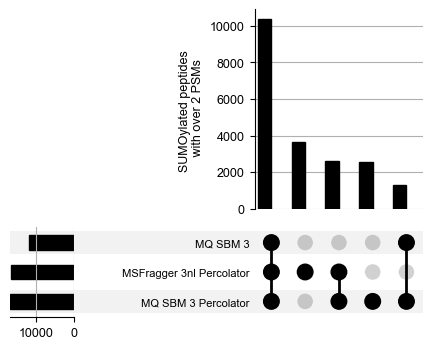

In [31]:
all_sets = {
    "MQ SBM 3": set_sbm3_psm2,
    "MQ SBM 3 Percolator": set_sbm3_per_psm2,
}


msfrag_sets_psm2 = {
    dataset: set(
        df.loc[df["No. of PSMs"] >= 2, "sumoylated_peptides"]
    )
    for dataset, df in msfragger_unique_sumo.groupby("Dataset")
}
all_sets.update(msfrag_sets_psm2)

all_sequences = set().union(*all_sets.values())

data = []
for sequence in all_sequences:
    row = [sequence in all_sets[name] for name in all_sets]
    row.append(sequence)
    data.append(row)

columns = list(all_sets.keys()) + ['id']

df_overlap = pd.DataFrame(data, columns=columns)
df_overlap.set_index(list(all_sets.keys()), inplace=True)

ax_dict = UpSet(
    df_overlap,
    subset_size="count",
    min_subset_size=500,
    show_counts=False,
    sort_by="cardinality"
).plot()

ax_dict["intersections"].set_ylabel("SUMOylated peptides \n with over 2 PSMs")
ax_dict["intersections"].tick_params(axis='both', labelsize=9)
ax_dict["totals"].tick_params(axis='both', labelsize=9)
ax_dict["intersections"].yaxis.label.set_size(9)

for label in ax_dict["matrix"].get_yticklabels():
    label.set_fontsize(8)

for bar in ax_dict['intersections'].patches:
    bar.set_width(0.4)
    bar.set_x(bar.get_x() - 0.15)

plt.gcf().savefig(
    fig_dir + "upset_plot_combined_2psms.pdf",
    format="pdf",
    transparent=True
)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_54655/595447238.py:44: FutureWarning: The default value of regex will change from True to False in a future version.
  .str.replace('\.', '')


5.0
1.0
1.0
2.0
2.0
1.0
1.0


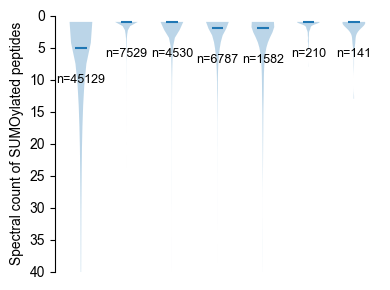

In [33]:
df_mq = (
    SBM3_SUMO_unique[['SUMOylated_peptide', 'No. of PSMs']]
    .rename(columns={'No. of PSMs': 'Count'})
    .assign(Dataset='MQ SBM 3')
)

df_perc = (
    df_sumo_per_unique[['peptide', 'No. of PSMs']]
    .rename(columns={'No. of PSMs': 'Count'})
    .rename(columns={'peptide': 'SUMOylated_peptide'})
    .assign(Dataset='MQ SBM 3 Percolator')
)

df_perc_rev = (
    df_sumo_per_unique_review[['peptide', 'No. of PSMs']]
    .rename(columns={'No. of PSMs': 'Count'})
    .rename(columns={'peptide': 'SUMOylated_peptide'})
    .assign(Dataset='Percolator_review')
)

df_perc_rev_reset = (
    df_sumo_per_unique_review_reset[['peptide', 'No. of PSMs']]
    .rename(columns={'No. of PSMs': 'Count'})
    .rename(columns={'peptide': 'SUMOylated_peptide'})
    .assign(Dataset='Percolator_review_reset')
)

df_msfrag = (
    msfragger_unique_sumo[['sumoylated_peptides', 'No. of PSMs']]
    .rename(columns={'No. of PSMs': 'Count'})
    .rename(columns={'sumoylated_peptides': 'SUMOylated_peptide'})
    .assign(Dataset='MSFragger 3nl Percolator')
)

combined = pd.concat(
    [df_mq, df_perc, df_msfrag],
    ignore_index=True
) 


combined['SUMOylated_peptide'] = (
    combined['SUMOylated_peptide']
    .str.replace(r'\[.*?\]', '', regex=True)
    .str.replace('\.', '')
    #.str.replace('_', '')
)

peptide_sets = (
    combined
    .groupby('SUMOylated_peptide')['Dataset']
    .apply(lambda x: frozenset(sorted(x)))
)

# Automatically generate readable labels
def make_label(s):
    if len(s) == 1:
        return f"{list(s)[0]} only"
    return " ∩ ".join(s)

peptide_labels = peptide_sets.apply(make_label)


combined['Overlap Set'] = combined['SUMOylated_peptide'].map(peptide_labels)

overlap_sizes = peptide_sets.value_counts().sort_values(ascending=False)
ordered_labels = overlap_sizes.index.map(make_label)


plt.figure(figsize=(4, 3))

order = sorted(
    combined['Overlap Set'].unique(),
    key=lambda x: (x.count('∩'), x)
)

data = [
    combined.loc[combined['Overlap Set'] == label, 'Count']
    for label in ordered_labels
]

vp = plt.violinplot(
    data,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

positions = range(1, len(ordered_labels) + 1)
plt.xticks(positions, ordered_labels, rotation=90, ha='right')

for i, values in enumerate(data, start=1):
    n = len(values)
    if n > 0:
        y = np.median(values) 
        print(y)
        plt.text(
            i,
            y + 5,
            f'n={n}',
            ha='center',
            va='center',
            fontsize=9,
            color='black'
        )

ax = plt.gca()
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.ylim(0, 40)
ax.set_xticks(positions)
ax.set_xticklabels([])
ax.xaxis.set_label_position('top')

ax.tick_params(axis='x', length=0)
plt.gca().invert_yaxis()

plt.ylabel('Spectral count of SUMOylated peptides')
plt.xlabel('')
plt.tight_layout()

file_path = fig_dir + "spectral_counts_violin.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')
plt.show()


# Score distributions

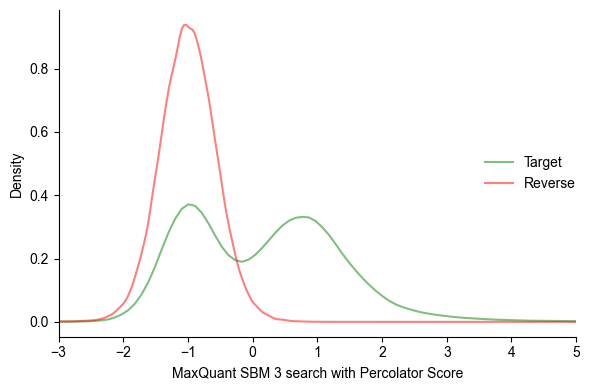

In [115]:
plt.figure(figsize=(6, 4))
ax = plt.gca()

bins = 800   # increase → smaller bins

df_per["score"].plot(
    kind="density",
    #bins=bins,
    #density=True,
    label="Target",
    color="green",
    alpha=0.5
)

df_per_decoys["score"].plot(
    kind="density",
    #bins=bins,
    #density=True,
    label="Reverse",
    color="red",
    alpha=0.5
)

plt.xlabel("MaxQuant SBM 3 search with Percolator Score")
plt.ylabel("Density")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-3, 5)

plt.legend()
plt.tight_layout()
legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(0.8, 0.5),
    frameon=False
)

file_path = fig_dir + "score_dist_mq_percolator.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')

plt.show()



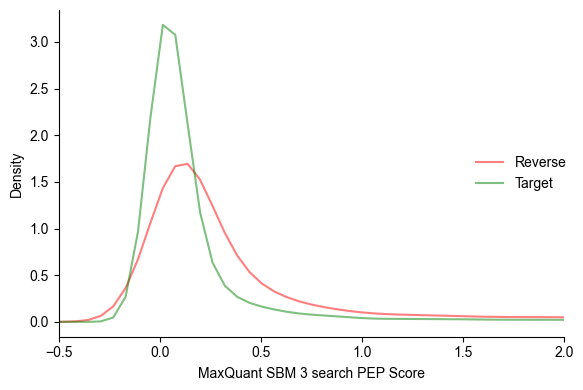

In [112]:
bins = 20000

plt.figure(figsize=(6, 4))
ax = plt.gca()

for rev_label, subset in no_fdr_set.groupby("Reverse"):
    
    if rev_label== "+":
        label = "Reverse"
        color = "red"
    elif rev_label== "-":
        label = "Target"
        color = "green"

    subset["PEP"].plot(
        kind="density", 
        #bins=bins,
        #density=True,
        label=label,
        color=color, 
        alpha = 0.5
    )

plt.xlabel("MaxQuant SBM 3 search PEP Score")
plt.ylabel("Density")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-0.5, 2)

legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(0.8, 0.5),
    frameon=False
)

plt.tight_layout()

file_path = fig_dir + "score_dist_mq_pep.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')

plt.show()
